# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/HarshiniChebrolu/Flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

The queue prioritizes content items using observed trend and recent performance signals.

Items showing a negative observed trend are placed earlier for review, with reason codes based on measurable signals such as changes in impressions, clicks, CTR, and content freshness.

The recommended actions are **REFRESH**, **CTR_FIX**, or **MONITOR**. These recommendations are decision-support only. They do not establish that taking an action will cause future traffic or ranking improvement.


In [2]:
import pandas as pd
import numpy as np
from google.colab import files

uploaded = files.upload()

file_name = next(iter(uploaded))

df = pd.read_csv(file_name)

print("Dataset shape:", df.shape)
display(df.head())

Saving content_refresh_anonymized (2).csv to content_refresh_anonymized (2).csv
Dataset shape: (30000, 44)


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


In [3]:
# Create the ranked action queue

queue = df.copy()

queue["impression_change"] = (
    queue["impressions_last_30d"] -
    queue["impressions_prev_30d"]
)

queue["click_change"] = (
    queue["clicks_last_30d"] -
    queue["clicks_prev_30d"]
)

# Priority is based on observed trend magnitude and impressions
queue["priority_score"] = (
    queue["trend_pct"].abs()
    * np.log1p(queue["impressions_last_30d"].clip(lower=0))
)

def get_reason(row):
    reasons = []

    if pd.notna(row["trend_pct"]) and row["trend_pct"] < 0:
        reasons.append("negative trend")

    if (
        pd.notna(row["impressions_last_30d"])
        and pd.notna(row["impressions_prev_30d"])
        and row["impressions_last_30d"] < row["impressions_prev_30d"]
    ):
        reasons.append("impressions down")

    if (
        pd.notna(row["clicks_last_30d"])
        and pd.notna(row["clicks_prev_30d"])
        and row["clicks_last_30d"] < row["clicks_prev_30d"]
    ):
        reasons.append("clicks down")

    if pd.notna(row["ctr"]) and row["ctr"] < 1:
        reasons.append("low CTR")

    if (
        pd.notna(row["days_since_last_update"])
        and row["days_since_last_update"] > 180
    ):
        reasons.append("stale content")

    return "; ".join(reasons[:3]) if reasons else "monitor"


queue["reason_code"] = queue.apply(get_reason, axis=1)


def get_action(row):
    if row["trend_direction"] == "down":
        if "low CTR" in row["reason_code"]:
            return "CTR_FIX"
        return "REFRESH"

    return "MONITOR"


queue["recommended_action"] = queue.apply(get_action, axis=1)

ranked_queue = (
    queue
    .sort_values("priority_score", ascending=False)
    .reset_index(drop=True)
)

display(
    ranked_queue[
        [
            "content_id",
            "recommended_action",
            "reason_code",
            "priority_score",
            "trend_direction",
            "trend_pct"
        ]
    ].head(20)
)

,content_id,recommended_action,reason_code,priority_score,trend_direction,trend_pct
0,content_a023517539fe,MONITOR,low CTR,342266.765172,up,27907.3
1,content_dd882c4152ac,MONITOR,low CTR,274404.883544,up,44900.0
2,content_d020d42e7fcc,MONITOR,low CTR,203276.880325,up,26166.7
3,content_4f1966b37335,MONITOR,low CTR,125420.607328,up,17077.8
4,content_22f4d2f58c42,MONITOR,low CTR,115030.957924,up,21400.0
5,content_aac5bd559d85,MONITOR,low CTR,113159.850566,up,15825.0
6,content_32ff84795595,MONITOR,low CTR,74757.469569,up,14900.0
7,content_ceedad7ba6dc,MONITOR,low CTR,71704.096795,up,11650.0
8,content_a6c4ef450727,MONITOR,low CTR,65739.062131,up,11266.7
9,content_4a6607efcb46,MONITOR,low CTR,63568.630599,up,5426.6


## 2. Intended use and limits

This playbook is intended for content teams to prioritize pages for human review.

It uses observed data patterns to identify content that may be worth reviewing first. The output is decision-support, not an automated decision system.

The recommendations are limited to the evaluated dataset and its available signals. They should not be interpreted as proof that a particular content action will improve future performance. Performance may differ for new clients, new content types, or data distributions that differ from the evaluated data.


In [4]:
# This cell is for CODE (numbers, a query, a check).
# Wriprint("=== INTENDED USE CHECK ===")

print("Rows available for decision-support:", len(ranked_queue))

print("\nRecommended actions:")
display(
    ranked_queue["recommended_action"]
    .value_counts()
    .rename_axis("action")
    .reset_index(name="count")
)

print("\nUnique content items:", ranked_queue["content_id"].nunique())

Rows available for decision-support: 30000

Recommended actions:


,action,count
0,MONITOR,13738
1,CTR_FIX,11376
2,REFRESH,4886



Unique content items: 30000


print("=== INTENDED USE CHECK ===")

print("Rows available for decision-support:", len(ranked_queue))

print("\nRecommended actions:")
display(
    ranked_queue["recommended_action"]
    .value_counts()
    .rename_axis("action")
    .reset_index(name="count")
)

print("\nUnique content items:", ranked_queue["content_id"].nunique())

In [5]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
required_review_columns = [
    "content_id",
    "recommended_action",
    "reason_code",
    "trend_direction",
    "trend_pct",
    "impressions_last_30d",
    "clicks_last_30d",
    "ctr"
]

review_queue = ranked_queue[required_review_columns].copy()

print("Human-review queue created.")
print("Rows:", len(review_queue))

display(review_queue.head(10))

Human-review queue created.
Rows: 30000


,content_id,recommended_action,reason_code,trend_direction,trend_pct,impressions_last_30d,clicks_last_30d,ctr
0,content_a023517539fe,MONITOR,low CTR,up,27907.3,212015,8,0.01
1,content_dd882c4152ac,MONITOR,low CTR,up,44900.0,450,0,0.00
2,content_d020d42e7fcc,MONITOR,low CTR,up,26166.7,2364,2,0.08
3,content_4f1966b37335,MONITOR,low CTR,up,17077.8,1546,4,0.16
4,content_22f4d2f58c42,MONITOR,low CTR,up,21400.0,215,0,0.00
5,content_aac5bd559d85,MONITOR,low CTR,up,15825.0,1274,0,0.00
6,content_32ff84795595,MONITOR,low CTR,up,14900.0,150,0,0.00
7,content_ceedad7ba6dc,MONITOR,low CTR,up,11650.0,470,5,0.94
8,content_a6c4ef450727,MONITOR,low CTR,up,11266.7,341,3,0.99
9,content_4a6607efcb46,MONITOR,low CTR,up,5426.6,122303,10,0.01


## 4. Monitoring / retrain triggers

The recommendations should be reviewed when the underlying data changes enough that the observed patterns may no longer represent the current dataset.

Useful monitoring signals include:

* Changes in the distribution of `trend_direction`.
* Changes in missing-value rates.
* Changes in feature distributions.
* Large changes in the number of items receiving each action.
* Declining measured validation performance on newer data.
* New content types or traffic patterns not represented during evaluation.

Retraining or re-validation should be considered when these changes are persistent and materially affect the inputs or measured performance.


In [6]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
print("=== MONITORING SNAPSHOT ===")

print("\nTrend distribution:")
display(
    df["trend_direction"]
    .value_counts(dropna=False)
    .rename_axis("trend_direction")
    .reset_index(name="count")
)

print("\nRecommended action distribution:")
display(
    ranked_queue["recommended_action"]
    .value_counts(dropna=False)
    .rename_axis("recommended_action")
    .reset_index(name="count")
)

print("\nMissing-value rate for key signals:")

key_columns = [
    "trend_pct",
    "impressions_last_30d",
    "clicks_last_30d",
    "ctr"
]

missing_rates = (
    df[key_columns]
    .isna()
    .mean()
    .mul(100)
    .round(2)
    .rename("missing_pct")
)

display(missing_rates.to_frame())

=== MONITORING SNAPSHOT ===

Trend distribution:


,trend_direction,count
0,down,16262
1,stable,5962
2,up,4388
3,new,2236
4,flat,1152



Recommended action distribution:


,recommended_action,count
0,MONITOR,13738
1,CTR_FIX,11376
2,REFRESH,4886



Missing-value rate for key signals:


,missing_pct
trend_pct,11.29
impressions_last_30d,0.00
clicks_last_30d,0.00
ctr,0.00


## 5. Exports for the paper

The ranked queue and reusable summary figure are exported for later analysis and paper preparation.

The exported queue contains the observed signals, recommendation, priority score, and reason code used for human review.


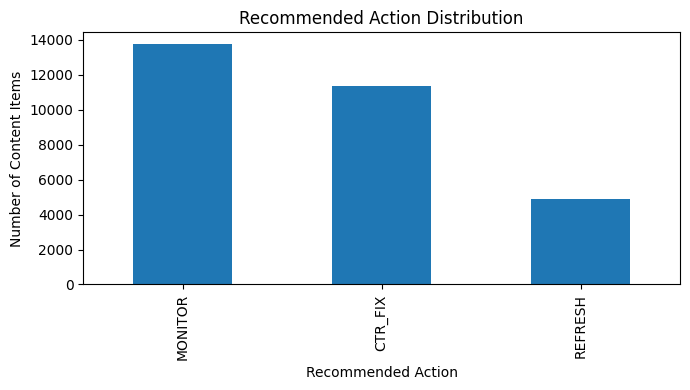

Queue saved to: work/outputs/content_action_queue.csv
Figure saved to: work/figures/recommended_action_distribution.png


In [7]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
from pathlib import Path
import matplotlib.pyplot as plt

output_dir = Path("work/outputs")
figure_dir = Path("work/figures")

output_dir.mkdir(parents=True, exist_ok=True)
figure_dir.mkdir(parents=True, exist_ok=True)

# Export ranked queue
queue_path = output_dir / "content_action_queue.csv"

ranked_queue[
    [
        "content_id",
        "recommended_action",
        "reason_code",
        "priority_score",
        "trend_direction",
        "trend_pct",
        "impressions_last_30d",
        "clicks_last_30d",
        "ctr",
        "days_since_last_update",
        "content_type"
    ]
].to_csv(queue_path, index=False)

# Create reusable figure
action_counts = ranked_queue["recommended_action"].value_counts()

plt.figure(figsize=(7, 4))
action_counts.plot(kind="bar")
plt.title("Recommended Action Distribution")
plt.xlabel("Recommended Action")
plt.ylabel("Number of Content Items")
plt.tight_layout()

figure_path = figure_dir / "recommended_action_distribution.png"
plt.savefig(figure_path, dpi=200, bbox_inches="tight")
plt.show()

print("Queue saved to:", queue_path)
print("Figure saved to:", figure_path)

In [8]:
print("=== ML-10 SELF-CHECK ===")

print("Dataset shape:", df.shape)
print("Queue rows:", len(ranked_queue))

print(
    "Reason codes complete:",
    ranked_queue["reason_code"].notna().all()
)

print(
    "Actions complete:",
    ranked_queue["recommended_action"].notna().all()
)

print("Queue export exists:", queue_path.exists())
print("Figure export exists:", figure_path.exists())

print("\nTop 10 ranked actions:")
display(
    ranked_queue[
        [
            "content_id",
            "recommended_action",
            "reason_code",
            "priority_score"
        ]
    ].head(10)
)

=== ML-10 SELF-CHECK ===
Dataset shape: (30000, 44)
Queue rows: 30000
Reason codes complete: True
Actions complete: True
Queue export exists: True
Figure export exists: True

Top 10 ranked actions:


,content_id,recommended_action,reason_code,priority_score
0,content_a023517539fe,MONITOR,low CTR,342266.765172
1,content_dd882c4152ac,MONITOR,low CTR,274404.883544
2,content_d020d42e7fcc,MONITOR,low CTR,203276.880325
3,content_4f1966b37335,MONITOR,low CTR,125420.607328
4,content_22f4d2f58c42,MONITOR,low CTR,115030.957924
5,content_aac5bd559d85,MONITOR,low CTR,113159.850566
6,content_32ff84795595,MONITOR,low CTR,74757.469569
7,content_ceedad7ba6dc,MONITOR,low CTR,71704.096795
8,content_a6c4ef450727,MONITOR,low CTR,65739.062131
9,content_4a6607efcb46,MONITOR,low CTR,63568.630599


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.